[*********************100%***********************]  1 of 1 completed


THE ACTUAL VALUES ARE

Ticker            TSLA
Date                  
2023-07-28  266.440002
2023-01-11  123.220001
2023-05-23  185.770004
2023-03-30  195.279999
2023-06-14  256.790009

THE PREDICTED VALUES ARE

            0
0  264.733490
1  124.991225
2  191.594406
3  196.792930
4  252.826223


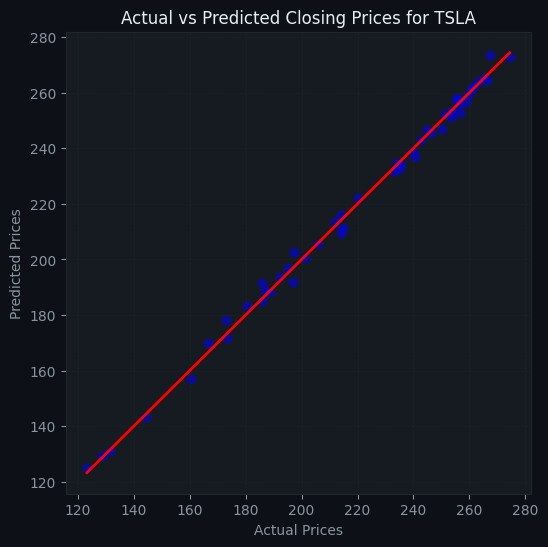

In [15]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Load historical data for Tesla (TSLA)
ticker = "TSLA"
data = yf.download(ticker, start="2023-01-01", end="2024-01-01")

# 2. Data Cleaning
data = data.dropna()

# 3. Define Features (X) and Target (y)
# We use Open, High, Low, and Volume to predict the Close price
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Close']

# 4. Split the data into Training and Testing sets
# 80% for training the model, 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Make Predictions
predictions = model.predict(X_test)

# 7. Compare Actual vs Predicted
# comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
# print(comparison_df.head())
actual=pd.DataFrame(y_test)
predicted=pd.DataFrame(predictions)
print(f"\nTHE ACTUAL VALUES ARE\n\n{actual.head()}")
print(f"\nTHE PREDICTED VALUES ARE\n\n{predicted.head()}")
# 8. Plot the results
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title(f'Actual vs Predicted Closing Prices for {ticker}')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()